In [27]:
import re
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset
%matplotlib inline

In [ ]:
# For plotting
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [6]:
class Value: # Using variables of this class enables the construction of the computations
             # graph. We need this in order to compute the backward pass
    def __init__(self, data, _children=(), _op = "", label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0 # the derivative of the Loss function with respect to this Value
        self._backward = lambda: None
        
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        res = Value(self.data + other.data, (self, other), "+") 
        def _backward(): # define the way in which the gradients should be backwarded through this operation
            self.grad += 1.0 * res.grad # accumulate the gradients
            other.grad += 1.0 * res.grad
        
        res._backward = _backward
        return res

    def __radd__(self, other):
        return self + other
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        res = Value(self.data * other.data, (self, other), "*")
       
        def _backward():  
            self.grad += other.data * res.grad
            other.grad += self.data * res.grad
        
        res._backward = _backward  
        
        return res

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        # this would be a different expression of the derivative if other would be a Value
        assert isinstance(other, (int, float)), "only int/float powers" 
        res = Value(self.data ** other, (self, ), f"**{other}")
        def _backward():
            self.grad += other * self.data ** (other-1) * res.grad
            
        res._backward = _backward
        return res

    def relu(self):
        res = Value(self.data if self.data>=0 else 0, (self,), "ReLU")
        def _backward():
            self.grad += res.grad if res.data>0 else 0
            
        res._backward = _backward
        return res
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        res = Value(t, (self, ), "tanh")
        def _backward():  
            self.grad += (1-t**2) * res.grad
            
        res._backward = _backward
        return res

    def sigmoid(self):
        x = self.data
        t = 1/(1+math.exp(-x))
        res = Value(t, (self, ), "Sigmoid")
        def _backward():
            self.grad += t*(1-t) * res.grad

        res._backward = _backward
        return res

    def log(self):
        x = self.data
        t = math.log(x)
        res = Value(t, (self, ), "log")
        def _backward():
            self.grad += 1/x * res.grad

        res._backward = _backward
        return res
        

    def exp(self):
        x = self.data
        res = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += res.data * res.grad
            
        res._backward = _backward
        return res        
        

    def backward(self): # in order to compute the gradients, we first sort the graph topologically
        topo_ordering = []
        visited = set()

        def visit_topo(n):
            if n not in visited:
                visited.add(n)
                for child in n._prev:
                    visit_topo(child)
                topo_ordering.append(n)
        visit_topo(self)

        self.grad = 1.0
        for node in reversed(topo_ordering):
            node._backward()

    def __repr__(self):
        return f"Value(data={self.data})"

    def __truediv__(self, other):
        return self * other**-1

    def __rtruediv__(self, other):
        return other * self**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __ge__(self, other):
        return self.data >= other.data

**This time the test dataset cluster.txt was used as an example. WikiText can also be used but I didn't have enough time to test on it**

In [119]:
# Hardcode the most common stopwords in the English language. For this PoC we will remove 
# them from the dataset because they introduce noise.
nltk_stopwords = {'be', 'our', 'being', 'did', 'what', 't', 'once', 'both', 'are', 'out', 'an', "wasn't", "we'll", 'been', 'which', 'them', 's', 'shan', 'against', 'from', "she'd", "should've", 'couldn', 'until', 'you', 
                  'more', 'through', 'by', 'him', 'the', "needn't", 'himself', 'needn', 'such', "he's", 'after', 'into', 'am', 'o', 'if', 'just', 'very', 'hasn', 'nor', 'as', 'for', 'it', 'about', 'herself', 'mustn', 
                  "weren't", 'these', 'between', "we've", 'above', "don't", 'only', 'they', 'most', "mustn't", 'he', 'over', "they'd", 'isn', 'up', 'weren', 'again', 'or', "haven't", "shouldn't", 'all', 'has', 
                  'itself', 'theirs', 'have', 'don', 'any', 'under', 'ours', 'ourselves', 'we', 'then', "aren't", 'should', 'won', 'too', "i'm", 'their', 'those', 'doesn', 'on', 'down', 'd', 'with', 
                  'hadn', 'than', 'of', "she'll", 'm', 'y', 'while', 'will', "he'll", "hadn't", "doesn't", 'her', 'own', 'where', 'hers', 'yours', "i've", 'who', "he'd", 'mightn', 'can', 'she', "i'd", 
                  "we'd", "they've", 'no', "i'll", 'and', "that'll", 'this', 'but', 'not', 'was', 'to', 'some', 'same', 'ma', 'didn', 'll', 'themselves', 'your', 'why', 'before', 'shouldn', 'wouldn', "mightn't", 'because', 
                  "didn't", "hasn't", "wouldn't", 'so', "you'd", "won't", 'a', 'yourself', 'me', 'wasn', "isn't", 'below', "you're", 'how', 'there', 'off', "they'll", 'when', "it's", "you'll", 've', 'each', 'do', 'whom', 'does', 'his', 'my', 'in', 'ain', "she's", 'its', "they're", 're', "we're", 'were', 'haven', 'here', 'myself', 'now', 'aren', 'having', 'further', 'at', 'during', 'had', 'i', 'doing', 'that', 'few', 'other', "you've", "couldn't", 'yourselves', "shan't", 'is', "it'd", "it'll"}


data_path = "/kaggle/input/datasets/catalinmihailazar/word2vec/group.txt"

# Used for local storage datasets
def load_text(data_path):
    with open(data_path, 'r', encoding='utf-8') as f:
        text = f.read().lower()
    return text

def load_wikitext2():
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

    # combine all of the splits
    text = " ".join(dataset["train"]["text"]).lower()

    # return only a part of the data for testing
    return text[:(len(text)//100)]


def tokenize(text):
    text = re.sub(r"[^a-zA-Z0-9\s]", ' ', text)  # remove punctuation
    text = re.sub(r"\s+", " ", text)
    words = text.split()
    words = [w for w in words if w not in nltk_stopwords] # keep all words except stopwords
    return words


# creating the vocabulary
def build_vocab(words):
    word_counts = Counter(words)
    vocabulary = {word: idx for idx, (word, _) in enumerate(word_counts.items())}
    idx_to_word = {idx: word for word, idx in vocabulary.items()}
    return vocabulary, idx_to_word, word_counts


def prepare_data_from_text(text, vocabulary, window_size=2):
    data = []
    
    # remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    
    # split by sentence-ending punctuation
    sentences = re.split(r'[.!?]', text)
    
    # Remove empty sentences
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]

    for sentence in sentences:
        words = tokenize(sentence)
        
        # skip sentences that are very short
        if len(words) < 2:
            continue
        
        for idx, word in enumerate(words):
            for neighbor in range(-window_size, window_size + 1):
                if neighbor == 0:
                    continue
                    
                neighbor_idx = idx + neighbor
                if 0 <= neighbor_idx < len(words):
                    data.append((vocabulary[word], vocabulary[words[neighbor_idx]]))
    
    return data

In [121]:
# create the vocabulary dictionary and the training data

# text = load_wikitext2()

text = load_text(data_path)
words = tokenize(text)
vocabulary, idx_to_word, word_counts = build_vocab(words)

vocab_size = len(vocabulary)
training_data = prepare_data_from_text(text, vocabulary, window_size=3)

In [122]:
print("Vocab size: ", vocab_size)
print("Training data size: ", len(training_data))

# Each tuple contains a center word (input) and the context word (output to be predicted)
print("Sample of training data: ", training_data[:10])

Vocab size:  12
Training data size:  36
Sample of training data:  [(0, 1), (0, 2), (0, 3), (1, 0), (1, 2), (1, 3), (2, 0), (2, 1), (2, 3), (3, 0)]


In [129]:
# define the center and context Embedding matrices
emb_size = 16
center_embeddings = [[Value(random.uniform(-1,1)) for _ in range(emb_size)] for i in range(vocab_size)]
context_embeddings = [[Value(random.uniform(-1,1)) for _ in range(emb_size)] for i in range(vocab_size)]

In [124]:
def dot_product(center_embedding, context_embedding):
    dot_res = Value(0.0)
    for idx in range(len(center_embedding)):
        dot_res+=center_embedding[idx] * context_embedding[idx]
    return dot_res

def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

In [125]:
# create the negative samples

def sample_negatives(no_negatives: int, center_index, context_index):
    sampled = []
    for _ in range(no_negatives):
        negative = center_index
        while (negative == center_index) or (negative == context_index) or (negative in sampled):
            negative = random.randint(0, vocab_size-1)
        sampled.append(negative)
    return sampled

In [130]:
# training loop

epochs = 7000
no_negatives = 1
lr = 0.001

for e in range(epochs):
    total_loss = 0
    np.random.shuffle(training_data)
    for i, training_sample in enumerate(training_data):
        center_index = training_sample[0]
        context_index = training_sample[1]
    
        center_emb = center_embeddings[center_index]
        context_emb_pos = context_embeddings[context_index]
        dot_pos = dot_product(center_emb, context_emb_pos)
        loss = Value(0.0, label="loss")
        loss_pos = -dot_pos.sigmoid().log() # -log(sigmoid(dot_pos))
        sampled_negatives = sample_negatives(no_negatives, center_index, context_index)
        
        loss_neg = Value(0.0)
        for neg_index in sampled_negatives:
            context_emb_neg = context_embeddings[neg_index]
            dot_neg = dot_product(center_emb, context_emb_neg)
            loss_neg += -(-dot_neg).sigmoid().log() # -log(1-sigmoid(dot_pos)) equivalent to -log(sigmoid(-dot_pos))
            
        loss = loss_pos + loss_neg
    
        neg_grad_flat = []
        for neg_index in sampled_negatives:
            neg_grad_flat.extend(context_embeddings[neg_index])
    
        params = center_embeddings[center_index] + context_embeddings[context_index] + neg_grad_flat
    
        for p in params:
            p.grad = 0
    
        loss.backward()
    
        # update
        for p in params:
            p.data -= lr * p.grad

        ##### Checks
        total_loss += loss.data

        # if i%10000==0:
        #     print(f"Step {i} | Loss: {loss.data:.6f}")

    if e % 1000 == 0:
        # Check Learning progress during training
        word1, word2, word3 = "cat", "dog", "apple"
        vec1 = [center_embeddings[vocabulary[word1]][i].data for i in range(emb_size)]
        vec2 = [center_embeddings[vocabulary[word2]][i].data for i in range(emb_size)]
        vec3 = [center_embeddings[vocabulary[word3]][i].data for i in range(emb_size)]

        similarity = cosine_similarity(vec1, vec2)
        print("cat-dog: ", similarity)      

        similarity = cosine_similarity(vec2, vec3)
        print("dog-apple: ", similarity)    

        
        print("Avg. loss: ", total_loss / len(training_data), "\n")

cat-dog:  -0.21761195994419097
dog-apple:  0.048736728752596506
Avg. loss:  1.821751360447183 

cat-dog:  0.02490925887879463
dog-apple:  0.14733861094284548
Avg. loss:  0.8327207131295 

cat-dog:  0.22886904610607445
dog-apple:  0.09452067812594782
Avg. loss:  0.9093094632453234 

cat-dog:  0.31799140449160646
dog-apple:  0.09184343493938649
Avg. loss:  0.6485248867135693 

cat-dog:  0.37416318437369817
dog-apple:  0.07861980357950231
Avg. loss:  0.66207501474648 

cat-dog:  0.4090473224537152
dog-apple:  0.08126926760362498
Avg. loss:  0.5052271327178912 

cat-dog:  0.433204761493889
dog-apple:  0.08155653762025036
Avg. loss:  0.5915784843661376 



In [ ]:
# check the most used words in the dataset
common_words = sorted(word_counts.items(), key=lambda x: -x[1])
words = [w for w, _ in common_words]
print(words[:50])

For cluster.txt


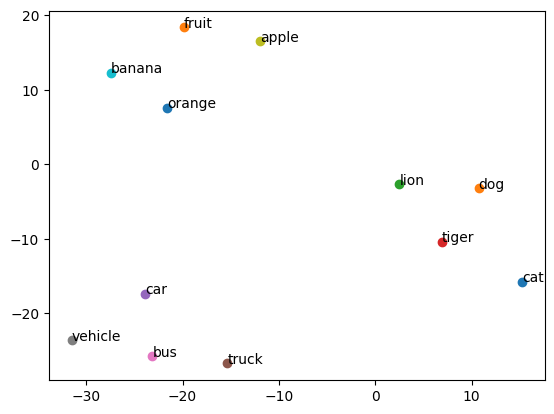

In [131]:
# Plot word embeddings to check training progress

# For cluster.txt dataset
words_cluster = ["cat", "dog", "lion", "tiger", "car", "truck", "bus", "vehicle", "apple", "banana", "orange", "fruit"]

# For wikitext
words_wiki = ["city", "country", "man", "woman", "year", "time", "world", "building", "tower", "house", "north", "south", "1","2","3","4","5","second","five"]

def plot_embeddings(words):

    # get embeddings from model
    vectors = []
    for w in words:
        emb = []
        emb_raw = center_embeddings[vocabulary[w]]
        for val in emb_raw:
            emb.append(val.data)
        vectors.append(emb)
    
    vectors = np.array(vectors)
    tsne = TSNE(n_components=2, perplexity=5, random_state=42)
    coords = tsne.fit_transform(vectors)
    
    
    for i, word in enumerate(words):
        x, y = coords[i]
        plt.scatter(x, y)
        plt.text(x, y, word)
    
    plt.show()


print("For cluster.txt")
plot_embeddings(words_cluster)

# print("For WikiText")
# plot_embeddings(words_wiki)